# Auditoria Final de NLP — Comparação dos Modelos de Sentimentos

Este notebook consolida os experimentos de **classificação de sentimentos em avaliações de e-commerce**, comparando os classificadores SVM selecionados com três representações textuais: **TF-IDF, Bag of Words com n-gramas e embeddings**.

Reutilizamos os modelos salvos e analisamos **acurácia, precisão, recall, F1 macro e matrizes de confusão**, considerando tanto o desempenho global quanto a identificação de avaliações negativas. A comparação encerra o projeto com uma discussão sobre as vantagens de cada abordagem e os critérios para sua utilização.

## 1. Importando as Bibliotecas

Importamos os recursos para preparar os textos, carregar os modelos salvos, calcular as métricas de classificação e visualizar as matrizes de confusão.

In [53]:
import pandas as pd
import numpy as np
import re
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import matplotlib.pyplot as plt

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## 2. Leitura e Preparação da Base

Carregamos a base tratada de avaliações, mantendo os comentários e seus respectivos sentimentos como referência para a comparação dos modelos.

In [3]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


### 2.1. Codificação dos Sentimentos

Convertimos os rótulos para **negativo (0)** e **positivo (1)**, mantendo a mesma interpretação das classes em todas as avaliações.

In [4]:
col_binaria = {
    "negativo": 0,
    "positivo": 1
}
dados["sentimento"] = dados["sentimento"].map(col_binaria)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,1
4,Parabéns lojas lannister adorei comprar pela I...,5,1
9,aparelho eficiente. no site a marca do aparelh...,4,1
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,1
15,"Vendedor confiável, produto ok e entrega antes...",5,1


## 3. Avaliação do Modelo com TF-IDF

Preparamos os comentários com limpeza, expansão de abreviações, tokenização, remoção de stopwords e stemização. As palavras de negação são mantidas na filtragem de stopwords. Os textos tratados serão encaminhados ao pipeline salvo de **TF-IDF + SVM**.

In [5]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

STOP_WORDS = set(stopwords.words("portuguese"))
NEGACAO = {"não", "nao", "nunca", "nem", "sem"}
STOP_WORDS_PT = STOP_WORDS - NEGACAO

In [8]:
stemmer = RSLPStemmer()

def limpeza_tfidf(texto):

    # 1. Lowercase
    texto = texto.lower()

    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)

    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)

    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)

    # 5. Expande contrações
    palavras = [CONTRACTIONS.get(p, p) for p in texto.split()]

    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéèêíìîóòôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    # 8. Tokenização
    tokens = word_tokenize(texto, language="portuguese")

    # 9. Stopwords + stemming
    resultado = []

    for token in tokens:

        if token.isalpha() and token not in STOP_WORDS_PT:
            token_stemmer = stemmer.stem(token)
            resultado.append(token_stemmer)

    return " ".join(resultado)


In [9]:
df_tfidf = dados.copy()
df_tfidf["review"] = df_tfidf["review_comment_message"].apply(limpeza_tfidf)
df_tfidf[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


### 3.1. Divisão dos Dados

Reservamos **30% dos dados para teste**, com estratificação dos sentimentos e andom_state=42. A reprodução do conjunto utilizado anteriormente depende da manutenção da mesma base, ordem dos registros e configuração da divisão.

In [32]:
X = df_tfidf["review"]
y = df_tfidf["sentimento"]

In [40]:
X_treino, X_teste_tfidf, y_treino, y_teste_tfidf = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

### 3.2. Carregamento e Previsão

Carregamos o pipeline salvo em modelo_tfidf_final.pkl e geramos as previsões para os textos de teste, sem realizar novo treinamento.

In [37]:
modelo_tfidf = joblib.load("../models/modelo_tfidf_final.pkl")

In [41]:
previsao_tfidf = modelo_tfidf.predict(X_teste_tfidf)

## 4. Avaliação do Modelo com BoW e N-gramas

Aplicamos a mesma função de limpeza utilizada nesta auditoria para TF-IDF e avaliamos o pipeline salvo de **Bag of Words com n-gramas + SVM**, que representa os textos por contagens de palavras e combinações de palavras.

In [15]:
df_bow_ngram = dados.copy()

df_bow_ngram["review"] = df_bow_ngram["review_comment_message"].apply(limpeza_tfidf)
df_bow_ngram[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


### 4.1. Divisão dos Dados

Repetimos a divisão estratificada com **30% para teste** e a mesma semente. Como as cópias preservam a ordem dos registros e os rótulos, os modelos são avaliados sobre os mesmos comentários.

In [42]:
X = df_bow_ngram["review"]
y = df_bow_ngram["sentimento"]

In [43]:
X_treino, X_teste_bow, y_treino, y_teste_bow = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

### 4.2. Carregamento e Previsão

Carregamos modelo_bow_ngram_final.pkl e aplicamos o pipeline aos comentários tratados para obter as previsões de sentimento.

In [16]:
modelo_bow_ngram = joblib.load("../models/modelo_bow_ngram_final.pkl")

In [44]:
previsao_bow_ngram = modelo_bow_ngram.predict(X_teste_bow)

## 5. Avaliação do Modelo com Embeddings

Utilizamos uma limpeza que mantém as palavras completas e a pontuação básica, sem remoção de stopwords ou stemização. Os comentários serão representados por **embeddings de sentenças** antes da classificação pelo SVM salvo.

In [18]:
def limpeza_embedding(texto):

    # 1. Lowercase
    texto = texto.lower()

    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)

    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)

    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)

    # 5. Expande contrações
    palavras = [CONTRACTIONS.get(p, p) for p in texto.split()]

    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéèêíìîóòôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto


In [19]:
df_embedding = dados.copy()

df_embedding["review"] = df_embedding["review_comment_message"].apply(limpeza_embedding)
df_embedding[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...","vendedor confiável, produto ok e entrega antes..."


### 5.1. Divisão dos Dados

Mantemos a mesma divisão estratificada e a mesma semente das abordagens anteriores, reservando os mesmos comentários para a avaliação com embeddings.

In [45]:
X = df_embedding["review"]
y = df_embedding["sentimento"]

In [46]:
X_treino, X_teste_emb, y_treino, y_teste_emb = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

### 5.2. Geração dos Embeddings

Carregamos o modelo pré-treinado **paraphrase-multilingual-MiniLM-L12-v2** e transformamos os comentários de teste em **vetores normalizados de 384 dimensões**, processados em lotes de 64 textos.

In [20]:
from sentence_transformers import SentenceTransformer

modelo_embedding = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [47]:
X_teste_embeddings = modelo_embedding.encode(
    X_teste_emb.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/176 [00:00<?, ?it/s]

### 5.3. Carregamento e Previsão

Carregamos o classificador de modelo_embeddings_final.pkl e geramos as previsões a partir dos vetores. O classificador depende da mesma representação e normalização utilizadas no treinamento.

In [48]:
modelo_embedding_final = joblib.load("../models/modelo_embeddings_final.pkl")

In [49]:
previsao_embedding = modelo_embedding_final.predict(X_teste_embeddings)

## 6. Comparação dos Resultados Finais

Reunimos as métricas dos três modelos nas **11.226 avaliações de teste**. As médias **macro** atribuem o mesmo peso às duas classes, permitindo complementar a acurácia em uma base com maior quantidade de avaliações positivas.

In [56]:
resultados_finais = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "Accuracy": accuracy_score(y_teste_tfidf, previsao_tfidf),
        "Precision Macro": precision_score(y_teste_tfidf, previsao_tfidf, average="macro"),
        "Recall Macro": recall_score(y_teste_tfidf, previsao_tfidf, average="macro"),
        "F1 Macro": f1_score(y_teste_tfidf, previsao_tfidf, average="macro")
    },
    {
        "Modelo": "BoW + N-gram + SVM",
        "Accuracy": accuracy_score(y_teste_bow, previsao_bow_ngram),
        "Precision Macro": precision_score(y_teste_bow, previsao_bow_ngram, average="macro"),
        "Recall Macro": recall_score(y_teste_bow, previsao_bow_ngram, average="macro"),
        "F1 Macro": f1_score(y_teste_bow, previsao_bow_ngram, average="macro")
    },
    {
        "Modelo": "Embeddings + SVM",
        "Accuracy": accuracy_score(y_teste_emb, previsao_embedding),
        "Precision Macro": precision_score(y_teste_emb, previsao_embedding, average="macro"),
        "Recall Macro": recall_score(y_teste_emb, previsao_embedding, average="macro"),
        "F1 Macro": f1_score(y_teste_emb, previsao_embedding, average="macro")
    }
])

resultados_finais.round(4)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,TF-IDF + SVM,0.9310,0.9088,0.9307,0.9186
1,BoW + N-gram + SVM,0.9313,0.9098,0.9296,0.9188
2,Embeddings + SVM,0.9278,0.9031,0.9335,0.9159


### 6.1. Análise das Métricas Globais

O **BoW + n-gramas + SVM** apresentou a maior acurácia (**93,13%**) e o maior **F1 macro (0,9188)**, seguido de perto pelo **TF-IDF + SVM (0,9186)**. Os **embeddings + SVM** alcançaram **F1 macro de 0,9159** e o maior **recall macro (0,9335)**. As diferenças são pequenas e, isoladamente, não demonstram superioridade estatística.

### 6.2. Desempenho por Classe

Os relatórios detalham precisão, recall e F1-score para cada sentimento. Essa leitura permite avaliar o equilíbrio entre identificar insatisfações e evitar que comentários positivos sejam classificados como negativos.

In [50]:
print("=== Modelo TF-IDF ===\n")
print(classification_report(y_teste_tfidf, previsao_tfidf))
print("-"*60)

print("\n=== Modelo Bow + Ngram ===\n")
print(classification_report(y_teste_bow, previsao_bow_ngram))
print("-"*60)

print("\n=== Modelo Embeddings ===\n")
print(classification_report(y_teste_emb, previsao_embedding))
print("-"*60)

=== Modelo TF-IDF ===

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------

=== Modelo Bow + Ngram ===

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      3267
           1       0.97      0.93      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.91      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------

=== Modelo Embeddings ===

              precision    recall  f1-score   support

           0       0.83      0.95      0.88      3267
           1       0.98      0.92  

### 6.3. Matrizes de Confusão

As matrizes mostram os acertos na diagonal principal e os erros fora dela. A classe **0 representa avaliações negativas** e a classe **1 representa avaliações positivas**.

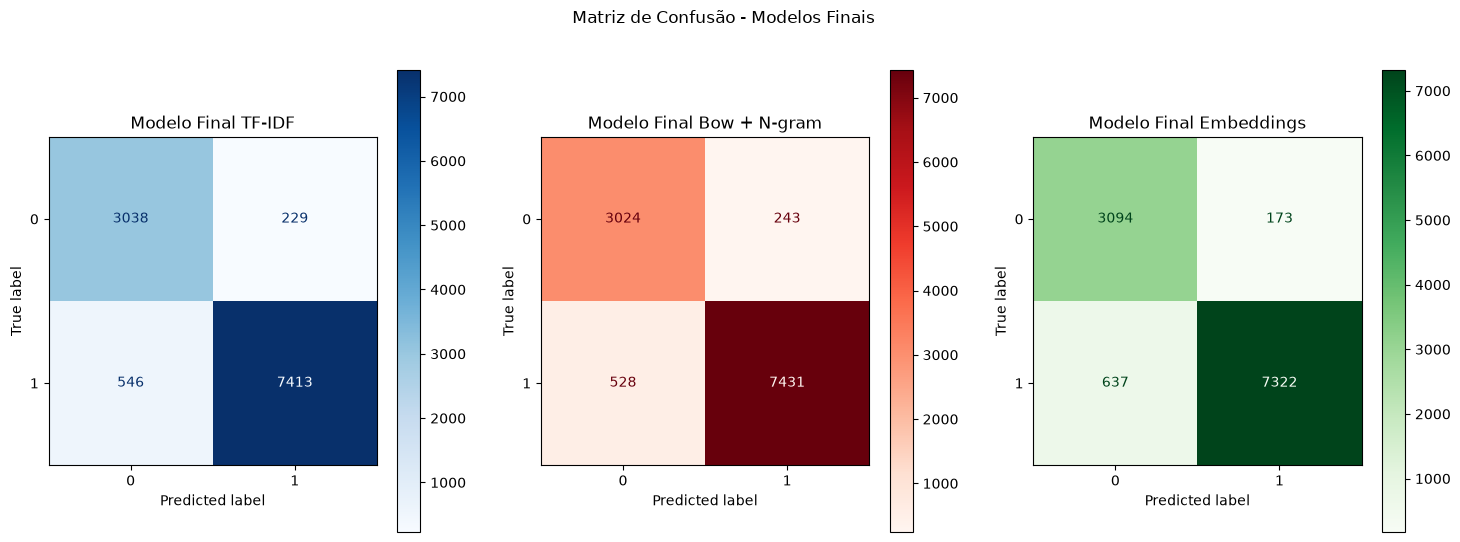

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


ConfusionMatrixDisplay.from_predictions(y_teste_tfidf, previsao_tfidf, cmap="Blues", ax=axes[0])
axes[0].set_title("Modelo Final TF-IDF")

ConfusionMatrixDisplay.from_predictions(y_teste_bow, previsao_bow_ngram, cmap="Reds", ax=axes[1])
axes[1].set_title("Modelo Final Bow + N-gram")

ConfusionMatrixDisplay.from_predictions(y_teste_emb, previsao_embedding, cmap="Greens", ax=axes[2])
axes[2].set_title("Modelo Final Embeddings")

plt.suptitle("Matriz de Confusão - Modelos Finais")
plt.show()

### 6.4. Análise dos Erros

O **BoW com n-gramas** cometeu **771 erros**, frente a **775 do TF-IDF** e **810 dos embeddings**. Entretanto, os embeddings deixaram passar menos avaliações negativas como positivas: **173**, contra **229 no TF-IDF** e **243 no BoW**. Essa maior sensibilidade às insatisfações veio acompanhada de **637 avaliações positivas classificadas como negativas**, aumentando os falsos alertas.

## 7. Conclusão da Auditoria

Para priorizar o **F1 macro**, o **BoW + n-gramas + SVM** é a referência de maior desempenho observado, com vantagem de apenas quatro acertos sobre o TF-IDF. Quando a prioridade é **identificar avaliações negativas**, os **embeddings + SVM** oferecem uma alternativa relevante, com recall próximo de **95%** nessa classe, ao custo de mais falsos alertas.

Os resultados mostram que a escolha depende do impacto de cada tipo de erro. Neste experimento, a representação por embeddings não superou as abordagens lexicais no F1 macro, mas favoreceu a detecção de insatisfações.

### 7.1. Limites e Próximos Passos

Esta auditoria consolida resultados de um conjunto de teste já consultado nos experimentos anteriores; não constitui uma validação independente. A comparação também envolve os pré-processamentos e ajustes de cada abordagem, não apenas a representação textual. Antes de adotar uma solução, convém confirmar a consistência com o treinamento, validar em uma amostra ainda não utilizada e considerar o custo dos erros e o tempo de previsão, que não foi medido aqui.